Shape: (1987, 10)
   Unnamed: 0  Age               Employment Type GraduateOrNot  AnnualIncome  \
0           0   31             Government Sector           Yes        400000   
1           1   31  Private Sector/Self Employed           Yes       1250000   
2           2   34  Private Sector/Self Employed           Yes        500000   
3           3   28  Private Sector/Self Employed           Yes        700000   
4           4   28  Private Sector/Self Employed           Yes        700000   

   FamilyMembers  ChronicDiseases FrequentFlyer EverTravelledAbroad  \
0              6                1            No                  No   
1              7                0            No                  No   
2              4                1            No                  No   
3              3                1            No                  No   
4              8                1           Yes                  No   

   TravelInsurance  
0                0  
1                0  
2          

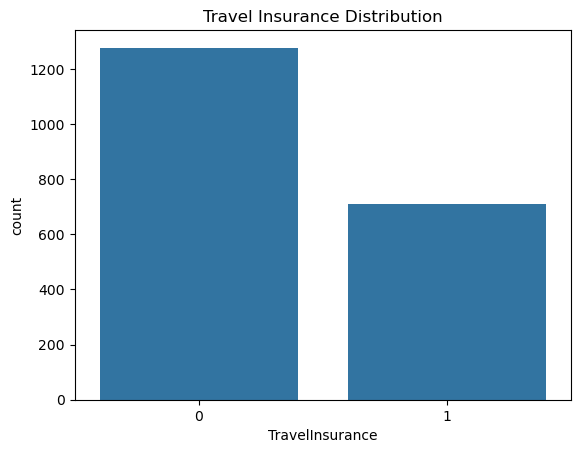

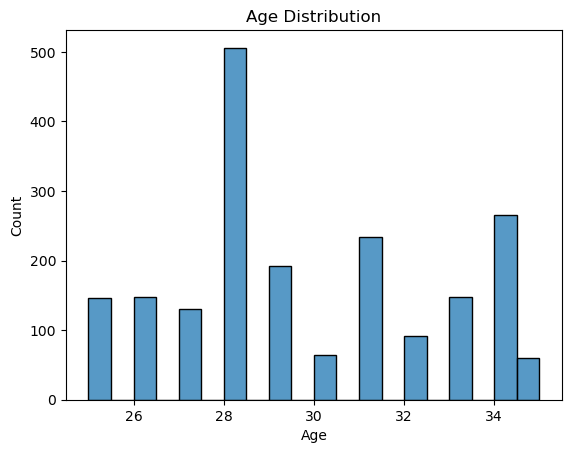

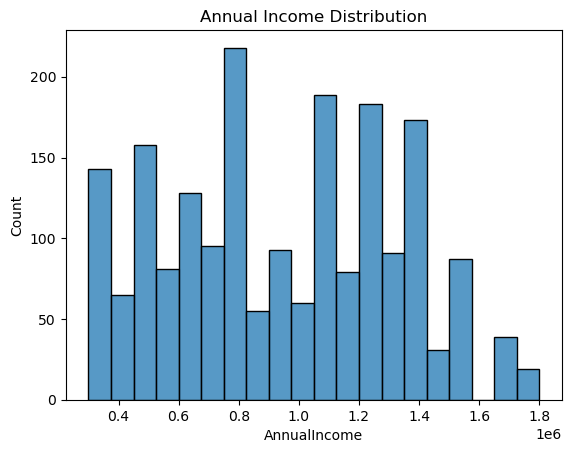

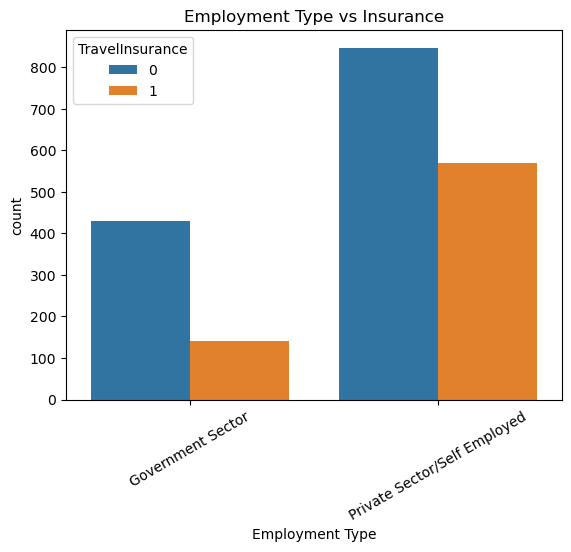

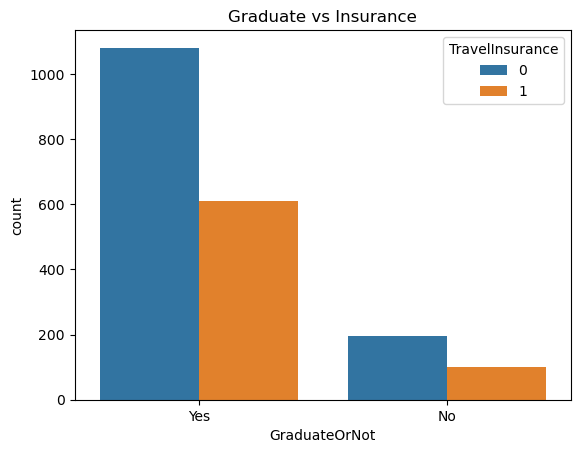

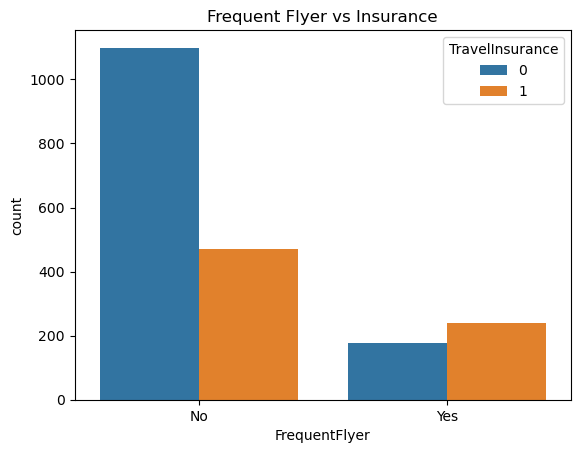

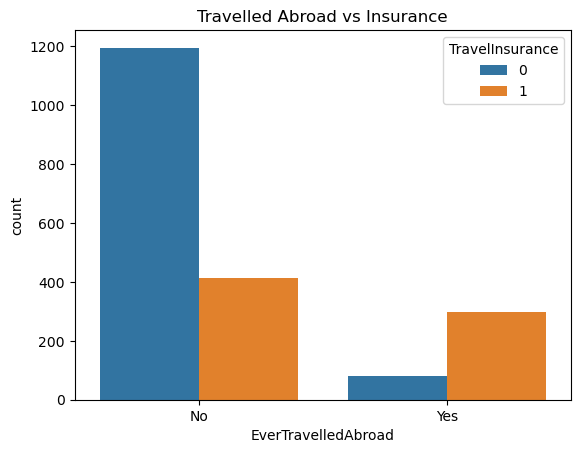

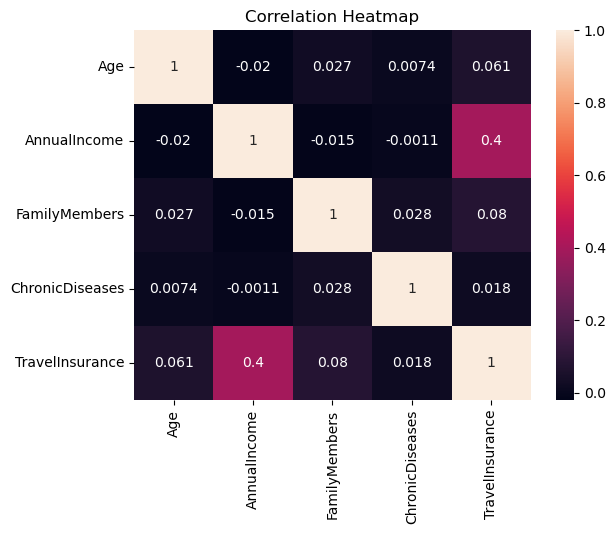

Logistic Regression Accuracy: 0.7688442211055276
Random Forest Accuracy: 0.8140703517587939

Random Forest Report:
               precision    recall  f1-score   support

           0       0.82      0.91      0.86       257
           1       0.80      0.64      0.71       141

    accuracy                           0.81       398
   macro avg       0.81      0.77      0.79       398
weighted avg       0.81      0.81      0.81       398



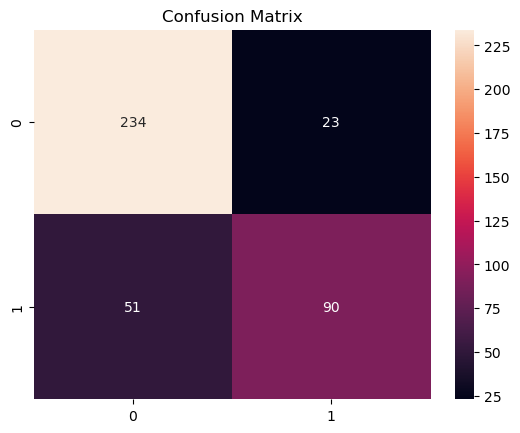

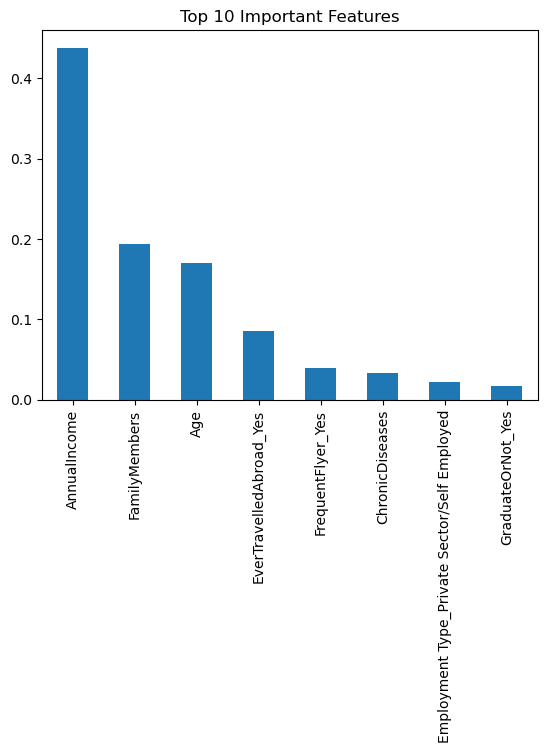


Sample Prediction (0 = No, 1 = Yes): 0

Project Completed Successfully


In [5]:
# =========================================
# TRAVEL INSURANCE PREDICTION (EDA + ML)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv('TravelInsurancePrediction.csv')

print("Shape:", df.shape)
print(df.head())

# -----------------------------
# Data Cleaning
# -----------------------------
df.drop('Unnamed: 0', axis=1, inplace=True)

# -----------------------------
# Basic Info
# -----------------------------
print(df.info())
print(df.describe())

# -----------------------------
# Visualization
# -----------------------------

# Target Distribution
plt.figure()
sns.countplot(x='TravelInsurance', data=df)
plt.title("Travel Insurance Distribution")
plt.show()

# Age Distribution
plt.figure()
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

# Income Distribution
plt.figure()
sns.histplot(df['AnnualIncome'], bins=20)
plt.title("Annual Income Distribution")
plt.show()

# Employment Type vs Insurance
plt.figure()
sns.countplot(x='Employment Type', hue='TravelInsurance', data=df)
plt.title("Employment Type vs Insurance")
plt.xticks(rotation=30)
plt.show()

# Graduate vs Insurance
plt.figure()
sns.countplot(x='GraduateOrNot', hue='TravelInsurance', data=df)
plt.title("Graduate vs Insurance")
plt.show()

# Frequent Flyer vs Insurance
plt.figure()
sns.countplot(x='FrequentFlyer', hue='TravelInsurance', data=df)
plt.title("Frequent Flyer vs Insurance")
plt.show()

# Abroad Travel vs Insurance
plt.figure()
sns.countplot(x='EverTravelledAbroad', hue='TravelInsurance', data=df)
plt.title("Travelled Abroad vs Insurance")
plt.show()

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -----------------------------
# Encoding
# -----------------------------
df = pd.get_dummies(df, drop_first=True)

# -----------------------------
# Split Data
# -----------------------------
from sklearn.model_selection import train_test_split

X = df.drop('TravelInsurance', axis=1)
y = df['TravelInsurance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Scaling
# -----------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# ML Models
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Important Features")
plt.show()

# -----------------------------
# Sample Prediction
# -----------------------------
sample = X_test[0].reshape(1, -1)
prediction = rf.predict(sample)

print("\nSample Prediction (0 = No, 1 = Yes):", prediction[0])

print("\nProject Completed Successfully")